<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 6</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Arbres de décision</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : structure et visualisation d'un arbre, critères de classification (entropie, gain d'information, rapport de gain et indice de Gini) et de régression (MSE et MAE), élagage par complexité-coût, classification CART, compromis biais-variance, instabilité structurelle et limites des arbres. Les exemples reposent sur les jeux de données <i>Iris</i>, <i>Wine</i> et <i>diabetes</i>. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `scipy` et `scikit-learn` (≥ 1.8).  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration. Les résultats des arbres peuvent varier légèrement selon la version de `scikit-learn`, en raison des règles de départage en cas d'égalité de gain.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scipy', 'scikit-learn')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuages de données / éléments neutres
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scipy              1.18.0
scikit-learn       1.9.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#127924;</span> Figure : Arbre de décision d'introduction sur le jeu de données Iris (max_depth=3) et représentation textuelle</h3>

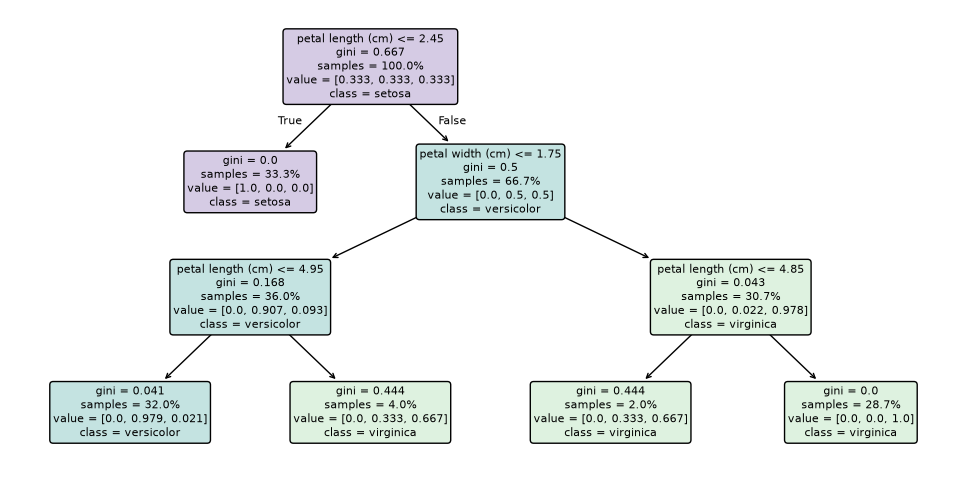

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Zones pâles des espèces (conventions du livre) :
# setosa, versicolor, virginica
palette = {0: '#d5cbe4', 1: '#c4e3e1', 2: '#def2e0'}

# Arbre d'introduction : ensemble complet, profondeur maximale 3
data = load_iris()
arbre_intro = DecisionTreeClassifier(max_depth=3, random_state=42)
arbre_intro.fit(data.data, data.target)

fig, ax = plt.subplots(figsize=(10, 5))

artistes = plot_tree(arbre_intro,
                     feature_names=data.feature_names,
                     class_names=data.target_names,
                     filled=True, rounded=True, proportion=True,
                     fontsize=8, ax=ax)

# Recoloration des nœuds selon la classe majoritaire
# (on écarte les étiquettes True/False, qui sont aussi des annotations)
noeuds = [a for a in artistes if 'gini' in a.get_text()]
for ann, val in zip(noeuds, arbre_intro.tree_.value):
    ann.set_bbox(dict(boxstyle='round', edgecolor='black',
                      facecolor=palette[int(val[0].argmax())]))

fig.tight_layout()
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig_Chap6_ExempleIntro")

In [4]:
# Représentation textuelle des règles de décision
print(export_text(arbre_intro, feature_names=data.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.1 : Recherche manuelle du seuil optimal par balayage exhaustif sur l'attribut petal length du jeu de données Iris</h3>

In [5]:
import numpy as np
from sklearn.datasets import load_iris

# Chargement de l'attribut petal length
data = load_iris()
x = data.data[:, 2]
y = data.target

# Entropie d'un vecteur de classes
def entropie(y):
    _, effectifs = np.unique(y, return_counts=True)
    p = effectifs / effectifs.sum()
    return -(p * np.log2(p)).sum()

# Seuils candidats : points médians entre valeurs consécutives
valeurs = np.sort(np.unique(x))
seuils  = (valeurs[:-1] + valeurs[1:]) / 2

# Balayage exhaustif des seuils
H_parent = entropie(y)
meilleur_ig, meilleur_seuil = -1.0, None
for tau in seuils:
    gauche, droite = y[x <= tau], y[x > tau]
    ig = (H_parent
        - len(gauche) / len(y) * entropie(gauche)
        - len(droite) / len(y) * entropie(droite))
    if ig > meilleur_ig:
        meilleur_ig, meilleur_seuil = ig, tau

print(f"Entropie de la racine : {H_parent:.4f}")
print(f"Seuil optimal τ*      : {meilleur_seuil:.2f}")
print(f"Gain d'information    : {meilleur_ig:.4f}")

Entropie de la racine : 1.5850
Seuil optimal τ*      : 2.45
Gain d'information    : 0.9183


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.2 : Chargement du jeu de données Iris et séparation entraînement/test</h3>

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Chargement des données Iris
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names

# Séparation des données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.3 : Calcul comparatif du gain d'information et du rapport de gain par attribut sur le jeu de données Iris</h3>

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
from sklearn.feature_selection import mutual_info_classif

# Étape 1 : Gain d'information pour chaque attribut
ig = mutual_info_classif(X, y, random_state=42)

# Étape 2 : Information de partition SI(t, A) pour chaque attribut
def split_information(X_col, n_bins=10):
    counts, _ = np.histogram(X_col, bins=n_bins)
    counts = counts[counts > 0]
    p = counts / counts.sum()
    return entropy(p, base=2)

si = np.array([split_information(X[:, j]) for j in range(X.shape[1])])

# Étape 3 : Rapport de gain = IG / SI
gr = np.where(si > 0, ig / si, 0)

# Organiser et afficher les résultats
df_resultats = pd.DataFrame({
    'Attribut': feature_names,
    'IG(t,A)' : ig.round(4),
    'SI(t,A)' : si.round(4),
    'GR(t,A)' : gr.round(4)
}).sort_values('GR(t,A)', ascending=False)

# --- Affichage ---
L = 61
print("=" * L)
print("Gain d'information et rapport de gain")
print("=" * L)
print(f"{'Attribut':<25}{'IG(t,A)':>12}"
      f"{'SI(t,A)':>12}{'GR(t,A)':>12}")
print("-" * L)

for _, ligne in df_resultats.iterrows():
    print(f"{ligne['Attribut']:<25}"
          f"{ligne['IG(t,A)']:>12.4f}"
          f"{ligne['SI(t,A)']:>12.4f}"
          f"{ligne['GR(t,A)']:>12.4f}")

print("=" * L)

Gain d'information et rapport de gain
Attribut                      IG(t,A)     SI(t,A)     GR(t,A)
-------------------------------------------------------------
petal length (cm)              0.9926      2.8460      0.3488
petal width (cm)               0.9856      2.8611      0.3445
sepal length (cm)              0.5114      3.1078      0.1645
sepal width (cm)               0.2994      2.8461      0.1052


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.4 : Comparaison des critères de Gini et d'entropie sur le jeu de données Iris</h3>

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Comparaison des critères Gini et entropie
resultats = []
for critere in ['gini', 'entropy']:
    arbre = DecisionTreeClassifier(criterion=critere, random_state=42)
    arbre.fit(X_train, y_train)
    exactitude = accuracy_score(y_test, arbre.predict(X_test))
    resultats.append({
        'Critere'    : critere,
        'Exactitude' : round(exactitude, 4),
        'Profondeur' : arbre.get_depth(),
        'Feuilles'   : arbre.get_n_leaves()
    })

df_resultats = pd.DataFrame(resultats)

# --- Affichage ---
L = 55
print("=" * L)
print("Comparaison des critères Gini et entropie")
print("=" * L)
print(f"{'Critère':<16}{'Exactitude':>14}"
      f"{'Profondeur':>13}{'Feuilles':>12}")
print("-" * L)

for _, ligne in df_resultats.iterrows():
    print(f"{ligne['Critere']:<16}"
          f"{ligne['Exactitude']:>14.4f}"
          f"{int(ligne['Profondeur']):>13}"
          f"{int(ligne['Feuilles']):>12}")

print("=" * L)

Comparaison des critères Gini et entropie
Critère             Exactitude   Profondeur    Feuilles
-------------------------------------------------------
gini                    1.0000            6          10
entropy                 0.9737            7          10


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.5 : Chargement du jeu de données diabetes et séparation entraînement/test</h3>

In [9]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Chargement des données diabetes
X, y = load_diabetes(return_X_y=True)

# Séparation des données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.6 : Comparaison des critères MSE et MAE sur le jeu de données diabetes</h3>

In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Comparaison des critères MSE et MAE
resultats = []
for critere in ['squared_error', 'absolute_error' ]:
    arbre = DecisionTreeRegressor(criterion=critere, random_state=42)
    arbre.fit(X_train, y_train)
    y_pred = arbre.predict(X_test)
    resultats.append({
        'Critere'    : critere,
        'R²'         : round(r2_score(y_test, y_pred), 4),
        'MSE'        : round(mean_squared_error(y_test, y_pred), 2),
        'MAE'        : round(mean_absolute_error(y_test, y_pred), 2),
        'Profondeur' : arbre.get_depth(),
        'Feuilles'   : arbre.get_n_leaves()
    })

# --- Affichage ---
L = 72
print("=" * L)
print("Comparaison des critères de division")
print("=" * L)
print(f"{'Critère':<18}{'R²':>9}{'MSE':>11}{'MAE':>10}"
      f"{'Profondeur':>13}{'Feuilles':>11}")
print("-" * L)

for r in resultats:
    print(f"{r['Critere']:<18}"
          f"{r['R²']:>9.4f}"
          f"{r['MSE']:>11.2f}"
          f"{r['MAE']:>10.2f}"
          f"{r['Profondeur']:>13}"
          f"{r['Feuilles']:>11}")

print("=" * L)

Comparaison des critères de division
Critère                  R²        MSE       MAE   Profondeur   Feuilles
------------------------------------------------------------------------
squared_error        0.0607    4976.80     54.53           19        346
absolute_error      -0.5018    7956.74     71.10           21        339


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.7 : Élagage par complexité-coût sur le jeu de données diabetes</h3>

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import numpy as np

# Séquence des alphas candidats (chemin d'élagage)
chemin = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = chemin.ccp_alphas[:-1]  # dernier alpha : racine seule

# Un arbre élagué par valeur de alpha
r2_test  = []
feuilles = []
for a in alphas:
    arbre = DecisionTreeRegressor(random_state=42, ccp_alpha=a)
    arbre.fit(X_train, y_train)
    r2_test.append(r2_score(y_test, arbre.predict(X_test)))
    feuilles.append(arbre.get_n_leaves())

# Sélection du meilleur alpha
i = np.argmax(r2_test)

# --- Affichage ---
L = 55
print("=" * L)
print("Élagage par coût-complexité (recherche de α*)")
print("=" * L)
print(f"Nombre de valeurs α candidates : {len(alphas)}")
print("-" * L)
print(f"{'Configuration':<30}{'R² test':<12}{'Feuilles'}")
print("-" * L)
print(f"{'Sans élagage (α = 0)':<30}{r2_test[0]:<12.4f}{feuilles[0]}")
print(f"{f'Avec élagage (α* = {alphas[i]:.2f})':<30}"
      f"{r2_test[i]:<12.4f}{feuilles[i]}")
print("=" * L)

Élagage par coût-complexité (recherche de α*)
Nombre de valeurs α candidates : 322
-------------------------------------------------------
Configuration                 R² test     Feuilles
-------------------------------------------------------
Sans élagage (α = 0)          0.0607      346
Avec élagage (α* = 80.58)     0.4513      8


<h3><span style="font-size: 30px">&#127924;</span> Figure : Élagage par complexité-coût : R² d'entraînement et de test en fonction de α</h3>

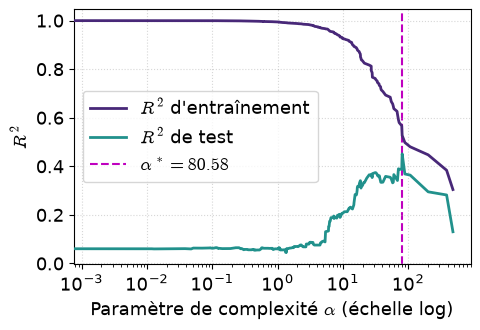

In [12]:
# R2 d'entraînement pour chaque alpha (complément de tracé)
r2_train = []
for a in alphas:
    arbre = DecisionTreeRegressor(random_state=42, ccp_alpha=a)
    arbre.fit(X_train, y_train)
    r2_train.append(r2_score(y_train, arbre.predict(X_train)))

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(alphas, r2_train, color=VIOLET, linewidth=2, zorder=3,
        label="$R^2$ d'entraînement")
ax.plot(alphas, r2_test, color=SARCELLE, linewidth=2, zorder=3,
        label='$R^2$ de test')
ax.axvline(alphas[i], color=MAGENTA, linestyle='--', linewidth=1.5,
           zorder=1, label=f'$\\alpha^* = {alphas[i]:.2f}$')

ax.set_xscale('log')
ax.set_xlabel('Paramètre de complexité $\\alpha$ (échelle log)')
ax.set_ylabel('$R^2$')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

# Sauvegarde de la figure
save_figure(fig, "Figures/Fig_Chap6_elagage_ccp")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.8 : Arbre de régression retenu par l'élagage sur le jeu de données diabetes</h3>

In [13]:
from sklearn.tree import DecisionTreeRegressor

# Arbre de régression retenu par l'élagage (alpha*)
arbre_elague = DecisionTreeRegressor(ccp_alpha=alphas[i], random_state=42)
arbre_elague.fit(X_train, y_train)

print("Profondeur :", arbre_elague.get_depth())
print("Feuilles   :", arbre_elague.get_n_leaves())
print("R² (test)  :", round(r2_score(y_test, arbre_elague.predict(X_test)), 4))

Profondeur : 5
Feuilles   : 8
R² (test)  : 0.4513


<h3><span style="font-size: 30px">&#127924;</span> Figure : Arbre de régression élagué (α*, 8 feuilles) sur le jeu de données diabetes</h3>

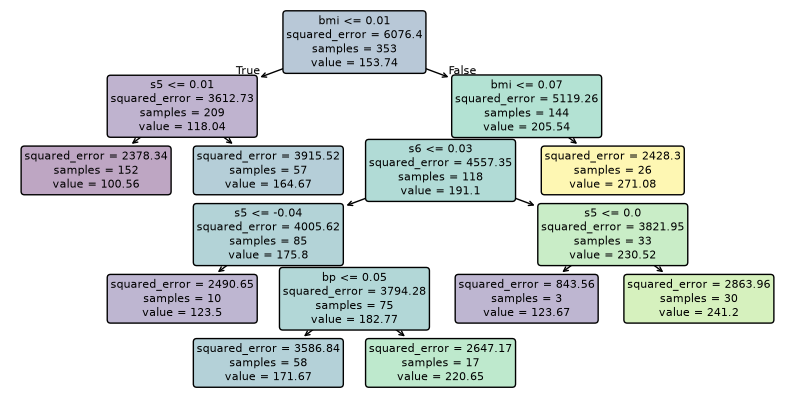

In [14]:
from matplotlib.colors import Normalize
from sklearn.tree import plot_tree
from sklearn.datasets import load_diabetes

noms = load_diabetes().feature_names

fig, ax = plt.subplots(figsize=(10, 5))

artistes = plot_tree(arbre_elague, feature_names=noms,
                     filled=True, rounded=True, fontsize=8,
                     precision=2, ax=ax)

# Teinte de fond : viridis pâle selon la valeur moyenne du nœud
valeurs = arbre_elague.tree_.value.ravel()
norme = Normalize(vmin=valeurs.min(), vmax=valeurs.max())
noeuds = [a for a in artistes if 'squared_error' in a.get_text()]
for ann, v in zip(noeuds, valeurs):
    base = plt.cm.viridis(norme(v))
    pale = tuple(0.35 * c + 0.65 for c in base[:3])
    ann.set_bbox(dict(boxstyle='round', edgecolor='black',
                      facecolor=pale))
plt.show()

# Sauvegarde de la figure
save_figure(fig, "Figures/Fig_Chap6_ArbreRegElague")

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.9 : Chargement et préparation des données Wine</h3>

In [15]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Chargement des données Wine
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names
class_names   = data.target_names

# Séparation des données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.10 : Entraînement de l'arbre de décision CART sur le jeu de données Wine</h3>

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Instanciation du modèle
cart = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)

# Entraînement du modèle
cart.fit(X_train, y_train)

# Tailles des ensembles et structure de l'arbre
print("Taille ensemble entrainement : ", len(X_train), "observations")
print("Taille ensemble test         : ",len(X_test), "observations")
print("Profondeur de l'arbre :", cart.get_depth())
print("Nombre de feuilles    :", cart.get_n_leaves())

Taille ensemble entrainement :  133 observations
Taille ensemble test         :  45 observations
Profondeur de l'arbre : 4
Nombre de feuilles    : 8


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.11 : Évaluation des performances du classificateur CART sur le jeu de données Wine</h3>

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Évaluation
y_pred = cart.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# --- Affichage ---
rapport = classification_report(y_test, y_pred,
                                target_names=list(class_names))

df_cm = pd.DataFrame(cm, index=class_names, 
                     columns=class_names)

print(f"Exactitude (test) : {acc:.3f}\n")
print("Classification report :")
print(rapport)
print("\nMatrice de confusion :")
print(df_cm)

Exactitude (test) : 0.956

Classification report :
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45


Matrice de confusion :
         class_0  class_1  class_2
class_0       14        1        0
class_1        0       18        0
class_2        0        1       11


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.12 : Importance des variables du classificateur CART sur le jeu de données Wine</h3>

In [18]:
import pandas as pd

# Importance des variables
importances = pd.Series(
    cart.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# --- Affichage ---

L = 55
print("=" * L)
print("Importance des variables du classificateur CART")
print("=" * L)
print(f"{'Variable':<35}{'Importance':>12}")
print("-" * L)

for variable, importance in importances.items():
    print(f"{variable:<35}{importance:>12.4f}")

print("=" * L)

Importance des variables du classificateur CART
Variable                             Importance
-------------------------------------------------------
flavanoids                               0.4108
color_intensity                          0.4033
proline                                  0.1003
od280/od315_of_diluted_wines             0.0224
alcalinity_of_ash                        0.0222
ash                                      0.0214
malic_acid                               0.0196
magnesium                                0.0000
alcohol                                  0.0000
proanthocyanins                          0.0000
nonflavanoid_phenols                     0.0000
total_phenols                            0.0000
hue                                      0.0000


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.13 : Effet de la profondeur maximale sur le compromis biais-variance sur le jeu de données Wine</h3>

In [19]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Chargement et préparation des données
data = load_wine()
X    = data.data
y    = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y)

# Calcul des exactitudes pour chaque profondeur
profondeurs = range(1, 20)
acc_train   = []
acc_test    = []

for d in profondeurs:
    arbre = DecisionTreeClassifier(criterion='gini', max_depth=d,random_state=42)
    arbre.fit(X_train, y_train)
    acc_train.append(accuracy_score(y_train,arbre.predict(X_train)))
    acc_test.append(accuracy_score(y_test,arbre.predict(X_test)))

# Identification de la profondeur optimale
ecart     = np.array(acc_train) - np.array(acc_test)
d_optimal = list(profondeurs)[np.argmax(acc_test)]

# --- Affichage ---
L = 40
print("=" * L)
print("Sélection de la profondeur maximale")
print("=" * L)
print(f"{'Profondeur optimale d*':<30}{d_optimal}")
print("-" * L)
print(f"{'Exactitude entraînement':<30}{acc_train[d_optimal - 1]:.4f}")
print(f"{'Exactitude test':<30}{acc_test[d_optimal - 1]:.4f}")
print(f"{'Écart entraînement/test':<30}{ecart[d_optimal - 1]:.4f}")
print("=" * L)

Sélection de la profondeur maximale
Profondeur optimale d*        3
----------------------------------------
Exactitude entraînement       0.9925
Exactitude test               0.9556
Écart entraînement/test       0.0369


<h3><span style="font-size: 30px">&#127924;</span> Figure : Compromis biais-variance : exactitudes d'entraînement et de test en fonction de la profondeur maximale</h3>

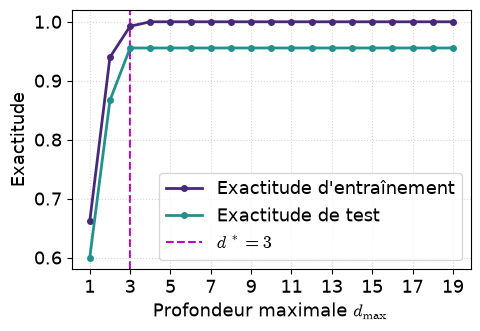

In [20]:
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(list(profondeurs), acc_train, 'o-', markersize=4, linewidth=2,
        zorder=3, color=VIOLET, label="Exactitude d'entraînement")
ax.plot(list(profondeurs), acc_test, 'o-', markersize=4, linewidth=2,
        zorder=3, color=SARCELLE, label='Exactitude de test')
ax.axvline(d_optimal, color=MAGENTA, linestyle='--', linewidth=1.5,
           zorder=1, label=f'$d^* = {d_optimal}$')

ax.set_xlabel('Profondeur maximale $d_{\\max}$')
ax.set_ylabel('Exactitude')
ax.set_xticks(list(profondeurs)[::2])
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

# Sauvegarde de la figure
save_figure(fig, "Figures/Fig_Chap6_profondeur_biais_variance")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.14 : Instabilité structurelle : deux arbres entraînés sur deux sous-échantillons du jeu de données Wine</h3>

In [21]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier

# Chargement des données

data = load_wine()
X = data.data
y = data.target

# Deux sous-échantillons aléatoires de 90 % des observations

L = 50
print("=" * L)
print("Instabilité de l'arbre selon le sous-échantillon")
print("=" * L)
print(f"{'Graine':<10}{'Variable à la racine':<25}{'Seuil'}")
print("-" * L)

for graine in [1, 4]:
    rng = np.random.RandomState(graine)
    idx = rng.choice(len(X), size=int(0.9 * len(X)), replace=False)
    arbre = DecisionTreeClassifier(max_depth=2, random_state=42)
    arbre.fit(X[idx], y[idx])
    racine = data.feature_names[arbre.tree_.feature[0]]
    seuil  = arbre.tree_.threshold[0]
    
    print(f"{graine:<10}{racine:<25}≤ {seuil:.2f}")

print("=" * L)

Instabilité de l'arbre selon le sous-échantillon
Graine    Variable à la racine     Seuil
--------------------------------------------------
1         proline                  ≤ 755.00
4         color_intensity          ≤ 3.82


<h3><span style="font-size: 30px">&#127924;</span> Figure : Deux arbres de profondeur 2 entraînés sur deux sous-échantillons de 90 % du jeu de données Wine</h3>

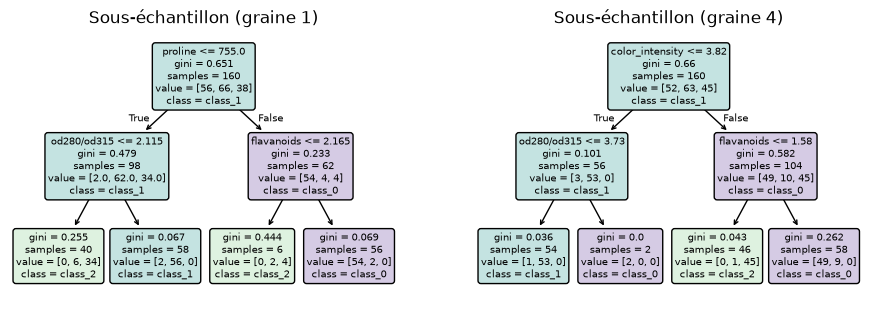

In [22]:
from sklearn.tree import plot_tree

# Nom abrégé pour l'attribut od280/od315_of_diluted_wines
noms_courts = ['od280/od315' if n.startswith('od280') else n
               for n in data.feature_names]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, graine in zip(axes, [1, 4]):
    rng = np.random.RandomState(graine)
    idx = rng.choice(len(X), size=int(0.9* len(X)), replace=False)
    arbre = DecisionTreeClassifier(max_depth=2, random_state=42)
    arbre.fit(X[idx], y[idx])
    artistes = plot_tree(arbre,
                         feature_names=noms_courts,
                         class_names=data.target_names,
                         filled=True, rounded=True, fontsize=7, ax=ax)
    # Même palette de classes que les figures du chapitre
    # (on écarte les étiquettes True/False)
    noeuds = [a for a in artistes if 'gini' in a.get_text()]
    for ann, val in zip(noeuds, arbre.tree_.value):
        ann.set_bbox(dict(boxstyle='round', edgecolor='black',
                          facecolor=palette[int(val[0].argmax())]))
    ax.set_title(f'Sous-échantillon (graine {graine})', fontsize=12)

plt.show()

# Sauvegarde de la figure
save_figure(fig, "Figures/Fig_Chap6_instabilite")


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.15 : Construction des frontières de décision pour deux profondeurs maximales sur le jeu de données Iris</h3>

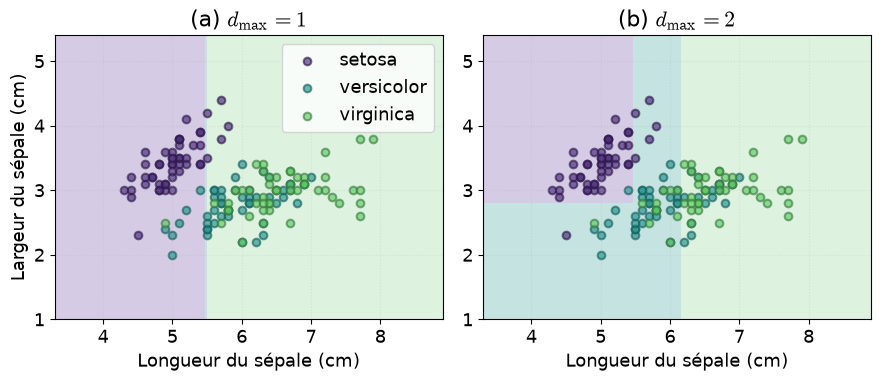

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# Deux attributs : longueur et largeur du sépale
data = load_iris()
X = data.data[:, :2]
y = data.target

# Profondeurs maximales étudiées
profondeurs = [1, 2]
titres = [r"(a) $d_{\max} = 1$", r"(b) $d_{\max} = 2$"]

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, d, titre in zip(axes, profondeurs, titres):
    # Entraînement de l'arbre
    arbre = DecisionTreeClassifier(criterion="gini", max_depth=d,
                                   random_state=42)
    arbre.fit(X, y)

    # Frontières de décision
    DecisionBoundaryDisplay.from_estimator(arbre, X, response_method="predict",
                                           multiclass_colors=[ZONE[VIOLET], ZONE[SARCELLE], ZONE[VERT]], ax=ax)

    # Observations
    for cls, coul in enumerate([VIOLET, SARCELLE, VERT]):
        ax.scatter(X[y == cls, 0], X[y == cls, 1],
                   color=coul, edgecolors=BORD[coul], linewidths=1.5,
                   s=30, alpha=0.65, label=data.target_names[cls])

    ax.set_title(titre)
    ax.set_xlabel("Longueur du sépale (cm)")
    ax.grid(alpha=0.25, linestyle=':')

# Axe vertical uniquement sur le premier graphique
axes[0].set_ylabel("Largeur du sépale (cm)")

# Légende
axes[0].legend()

plt.tight_layout()

# Sauvegarde de la figure
save_figure(fig, "Figures/Fig_Chap6_frontieres_decision_iris")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 6.16 : Approximation d'une relation linéaire bruitée par deux arbres de régression de profondeurs différentes</h3>

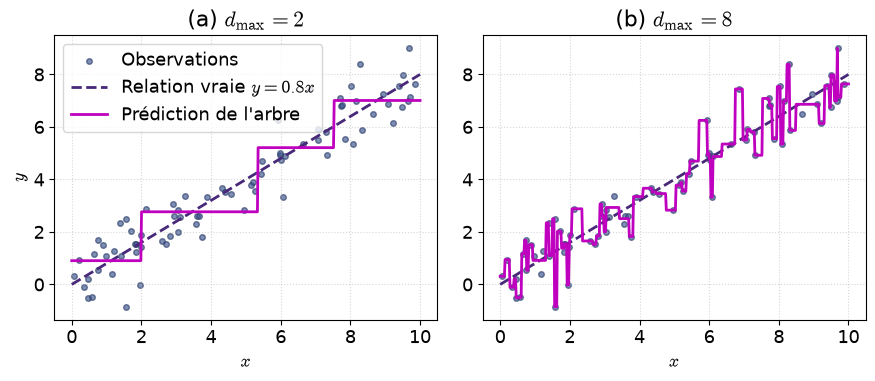

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Données synthétiques : relation linéaire bruitée
rng = np.random.RandomState(42)
m = 80
X = np.sort(rng.uniform(0, 10, m)).reshape(-1, 1)
y = 0.8 * X.ravel() + rng.normal(0, 0.8, m)

grille = np.linspace(0, 10, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, d, panneau in zip(axes, [2, 8], ["(a)", "(b)"]):
    arbre = DecisionTreeRegressor(max_depth=d, random_state=42)
    arbre.fit(X, y)

    # Observations, relation vraie et prédiction
    ax.scatter(X, y, s=16, color=BLEU, edgecolors=BORD[BLEU],
               linewidths=1, alpha=0.65, label='Observations')
    ax.plot(grille, 0.8 * grille.ravel(), color=VIOLET, linestyle='--',
            linewidth=2, label='Relation vraie $y = 0.8x$')
    ax.plot(grille, arbre.predict(grille), color=MAGENTA, linewidth=2,
            label="Prédiction de l'arbre")

    ax.set_title(f'{panneau} $d_{{\\max}} = {d}$')
    ax.set_xlabel('$x$')
    ax.grid(True, linestyle=':', alpha=0.5)

axes[0].set_ylabel('$y$')
axes[0].legend()

plt.tight_layout()

# Sauvegarde de la figure
save_figure(fig, "Figures/Fig_Chap6_regression_escalier")

plt.show()

<hr style='border-top:4px solid #1F77B4;'>